# Within-participant behaviour PLS

Within-participant behaviour PLS can be used to analyze trial-level associations between brain and behavioural data (e.g., subjective ratings). In this example, we will simulate a dataset where the strength of a stimulus is associated with the magnitude of an ERP on a trial-by-trial basis.

## Simulating data

We will simulate an experiment in which a stimulus evokes a parietally focused ERP. First, we will set up the underlying ERP timecourse.

Text(0.5, 1.0, 'Underlying ERP timecourse')

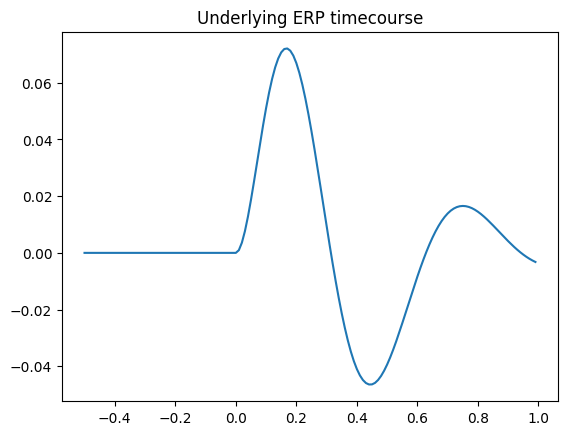

In [1]:
import mne
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import mne_plsc

np.random.seed(123)

# Set up underlying ERP timecourse
sfreq = 100
times = np.arange(-0.5, 1, 1/sfreq)
erp_timecourse = np.exp(-5*times) * times * np.sin(10*times)
erp_timecourse[times < 0] = 0
f, ax = plt.subplots()
ax.plot(times, erp_timecourse)
ax.set_title('Underlying ERP timecourse')

Next, we will set up the weights that will determine how strongly the ERP will be expressed at each channel.

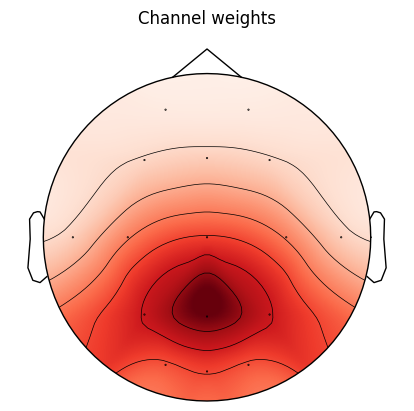

In [22]:
# Set up montage and info
montage = mne.channels.make_standard_montage('biosemi16')
ch_pos_dict = montage.get_positions()["ch_pos"]
ch_pos_array = np.array([ch_pos_dict[ch] for ch in montage.ch_names])
info = mne.create_info(ch_names=montage.ch_names,
                       ch_types='eeg',
                       sfreq=sfreq)
info = info.set_montage(montage)

# Function to get channel weights
center = ch_pos_dict['Pz']
dist = np.linalg.norm(ch_pos_array - center, axis=1)
chan_weights = np.exp(-(dist ** 2) / (2 * 0.075 ** 2))

f, ax = plt.subplots()
mne.viz.plot_topomap(chan_weights, info, axes=ax, show=False)
ax.set_title('Channel weights')
plt.show()

Finally, we will simulate the actual epochs per participant.

In [31]:
n_ptpts = 5
trials_per_ptpt = 20
all_epochs = []
for ptpt_n in range(n_ptpts):
    # Project ERP onto channels
    data = np.outer(chan_weights, erp_timecourse)
    data = np.stack([data]*trials_per_ptpt)
    # Simulate stimulus
    stim = np.random.gamma(shape=1, scale=1, size=(trials_per_ptpt,))
    # Scale ERP by stimulus
    data = data * stim.reshape((-1, 1, 1))
    # Add noise
    noise = 0.1*np.random.normal(size=data.shape)
    data = data + noise
    # Create epochs object
    epochs = mne.EpochsArray(data=data,
                             info=info,
                             metadata=pd.DataFrame({'stim': stim.squeeze()}),
                             verbose=False)
    all_epochs.append(epochs)

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: xlabel='Time (s)', ylabel='Salience'>,
        <Axes: ylabel='Correlation with brain score'>], dtype=object))

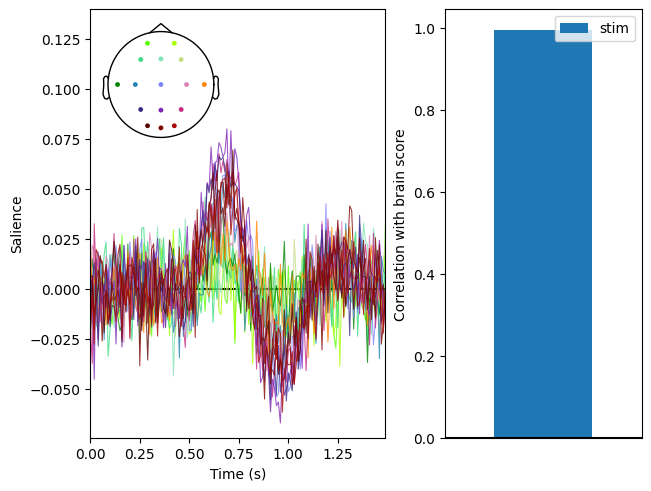

In [32]:
res = mne_plsc.fit_within_beh(data=all_epochs,
                              covariates='stim')
res.plot_lv(0)

In [33]:
res.permute(100)
print(res.summary())

Permuting: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 190.32it/s]

   LV index  singular value  variance explained   p value
0         0         8.36435                 1.0  0.009901


Resampling: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 102.02it/s]


Defaulting to all channels adjacent for ERP/ERF analysis
Clustering z-scores
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
41 clusters


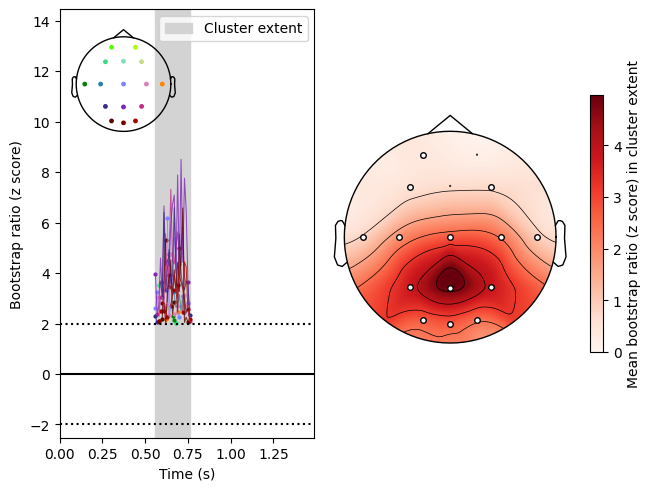

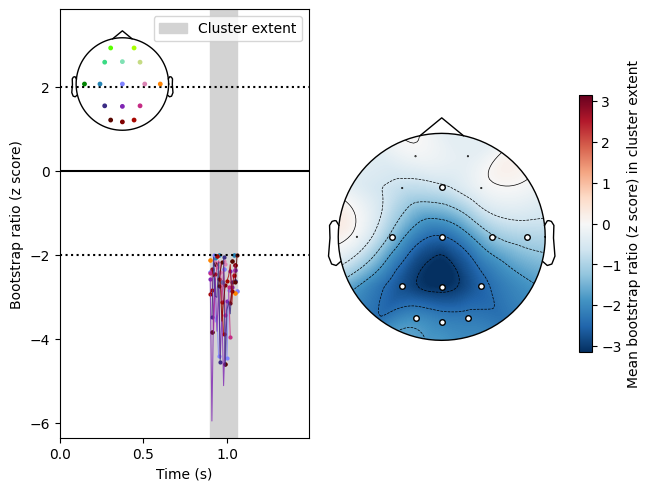

In [35]:
res.bootstrap(100)
res.add_adjacency(montage_name='biosemi16')
res.cluster()
res.plot_cluster(lv_idx=0, cluster_idx=0, highlight='extent')
res.plot_cluster(lv_idx=0, cluster_idx=1, highlight='extent')

In [ ]:
res.plot_marginal_brain_scores(lv_idx=0, margin='time')